In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter


import konlpy
from konlpy.tag import Mecab
import gensim
from gensim.models import KeyedVectors
from gensim.models.keyedvectors import Word2VecKeyedVectors
from gensim.models.word2vec import Word2Vec

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.nn.utils.rnn import pad_sequence

# init config
# 한글 폰트 설정 (주피터 노트북 시각화 대응)
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# 디바이스 지정 (GPU 가속 지원)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

# 데이터셋 기본 경로
base_path = os.path.join(os.getcwd(), '..', '..', 'work', 'sentiment_classification')

# 터미널에서 적용
'''
    konlpy, git, curl 설치되어있어야 함

    konlpy에서 mecab 쓰려면 아래 과정 진행
        sudo apt-get update
        sudo apt-get install --yes build-essential curl automake
        curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh | bash
        pip install mecab-python3
        (uv 환경: uv add mecab-python3)

    깃 레포 가져와서 konlpy mecab 설치 (안됨)
    git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
    cd Mecab-ko-for-Google-Colab/
    bash install_mecab-ko_on_colab_light_220429.sh
'''


In [51]:
# class define
class DataHandler:
    def __init__(self, tokenizer, stopwords=[]):
        self.tokenizer = tokenizer
        self.raw_train_data = None
        self.raw_test_data = None
        self.stopwords = stopwords

        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.word_index = None

    def load_data(self, train_data_path: str, test_data_path: str):
        '''
            train_data_path: file path(txt file only)
            test_data_path: file path(txt file only)
        '''
        if train_data_path.endswith('.txt') and test_data_path.endswith('.txt'):
            self.raw_train_data = pd.read_table(train_data_path)
            self.raw_test_data = pd.read_table(test_data_path)
        else:
            raise "tokenhandler class supported txt file only"

    def preprocessing(self, num_words=10000):
        if self.raw_train_data is None:
            raise "train_data is None"

        # 중복 제거
        self.raw_train_data.drop_duplicates(subset=['document'], inplace=True)
        self.raw_test_data.drop_duplicates(subset=['document'], inplace=True)
        # 결측 제거
        self.raw_train_data.dropna(how = 'any', inplace=True)        
        self.raw_test_data.dropna(how = 'any', inplace=True)

        X_train = []
        for sentence in self.raw_train_data['document']:
            temp_X = self.tokenizer.morphs(sentence) # 토큰화
            temp_X = [word for word in temp_X if not word in self.stopwords] # 불용어 제거
            X_train.append(temp_X)

        X_test = []
        for sentence in self.raw_test_data['document']:
            temp_X = self.tokenizer.morphs(sentence) # 토큰화
            temp_X = [word for word in temp_X if not word in self.stopwords] # 불용어 제거
            X_test.append(temp_X)

        words = np.concatenate(X_train).tolist()
        counter = Counter(words)
        counter = counter.most_common(10000-4)
        vocab = ['', '', '', ''] + [key for key, _ in counter]
        word_to_index = {word:index for index, word in enumerate(vocab)}

        def wordlist_to_indexlist(wordlist):
            return [word_to_index[word] if word in word_to_index else word_to_index[''] for word in wordlist]

        self.X_train = list(map(wordlist_to_indexlist, X_train))
        self.X_test = list(map(wordlist_to_indexlist, X_test))
        
        self.y_train = np.array(list(self.raw_train_data['label']))
        self.y_test = np.array(list(self.raw_test_data['label']))

        self.word_index = {index:word for word, index in word_to_index.items()}

    def get_preprocessed_train_test_data_and_word_to_index(self):
        return self.X_train, self.y_train, self.X_test, self.y_test, self.word_index


    # 문장 1개를 활용할 딕셔너리와 함께 주면, 단어 인덱스 리스트 벡터로 변환해 주는 함수입니다.
    # 단, 모든 문장은 <BOS>로 시작하는 것으로 합니다.
    def get_encoded_sentence(self, sentence, word_to_index):
        return [word_to_index['<BOS>']]+[word_to_index[word] if word in word_to_index else word_to_index['<UNK>'] for word in sentence.split()]

    # 여러 개의 문장 리스트를 한꺼번에 단어 인덱스 리스트 벡터로 encode해 주는 함수입니다.
    def get_encoded_sentences(self, sentences, word_to_index):
        return [self.get_encoded_sentence(sentence, word_to_index) for sentence in sentences]

    # 숫자 벡터로 encode된 문장을 원래대로 decode하는 함수입니다.
    def get_decoded_sentence(self, encoded_sentence, index_to_word):
        return ' '.join(index_to_word[index] if index in index_to_word else '<UNK>' for index in encoded_sentence[1:])  #[1:]를 통해 <BOS>를 제외

    # 여러 개의 숫자 벡터로 encode된 문장을 한꺼번에 원래대로 decode하는 함수입니다.
    def get_decoded_sentences(self, encoded_sentences, index_to_word):
        return [self.get_decoded_sentence(encoded_sentence, index_to_word) for encoded_sentence in encoded_sentences]


class LSTMModel(nn.Module):
    """1. LSTM 기반 순차 데이터 분류 모델"""
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, num_layers=1)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        embedded = self.embedding(x)
        out, (hidden, _) = self.lstm(embedded)
        # 마지막 타임스텝의 hidden state 활용
        return self.sigmoid(self.fc(hidden[-1])).squeeze(-1)


class CNNModel(nn.Module):
    """2. 1D-CNN 기반 합성곱 텍스트 분류 모델"""
    def __init__(self, vocab_size, embedding_dim, num_filters=128, filter_sizes=[3, 4, 5]):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embedding_dim, out_channels=num_filters, kernel_size=fs)
            for fs in filter_sizes
        ])
        self.fc = nn.Linear(len(filter_sizes) * num_filters, 1)
        self.dropout = nn.Dropout(0.5)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # [Batch, Seq_len] -> [Batch, Seq_len, Embedding_dim]
        embedded = self.embedding(x).permute(0, 2, 1) # [Batch, Embedding_dim, Seq_len]
        pooled_outputs = []
        for conv in self.convs:
            # Conv1d -> ReLU -> MaxPool1d
            c = torch.relu(conv(embedded))
            p = torch.max(c, dim=2)[0]
            pooled_outputs.append(p)
        
        flat = self.dropout(torch.cat(pooled_outputs, dim=1))
        return self.sigmoid(self.fc(flat)).squeeze(-1)


class GlobalPoolingModel(nn.Module):
    """3. Global Average Pooling 기반 경량 모델"""
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.fc1 = nn.Linear(embedding_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        embedded = self.embedding(x) # [Batch, Seq_len, Embedding_dim]
        pooled = torch.mean(embedded, dim=1) # Global Average Pooling
        out = torch.relu(self.fc1(pooled))
        return self.sigmoid(self.fc2(out)).squeeze(-1)
    

class TrainHandler:
    def __init__(self, base_path, X_train, y_train, X_test, y_test, word_index):
        self.base_path = base_path
        self.raw_X_train = X_train
        self.raw_y_train = y_train
        self.raw_X_test = X_test
        self.raw_y_test = y_test
        self.word_index = word_index # DataHandler에서 넘어온 {index: word} 구조
        self.vocab_size = len(word_index) + 4 # 패딩 및 특수토큰 여유 공간 확보
        
        # 전처리 완료 후 빌드될 텐서 및 데이터로더 스토리지
        self.X_train_padded = None
        self.X_test_padded = None
        self.train_loader = None
        self.val_loader = None
        self.test_loader = None
        
        # 모델 및 결과 아카이브
        self.models = {}
        self.histories = {}

    def analyze_data(self, max_len=None):
        """3) 문장 길이 분포 분석 및 pad_sequence 기반 패딩 추가"""
        lengths = [len(seq) for seq in self.raw_X_train]
        print("===== [데이터 분포 분석] =====")
        print(f"최대 문장 길이: {np.max(lengths)}")
        print(f"최소 문장 길이: {np.min(lengths)}")
        print(f"평균 문장 길이: {np.mean(lengths):.2f}")
        print(f"표준 편차: {np.std(lengths):.2f}")
        
        # 적절한 최대 문장 길이 지정 알고리즘 (평균 + 2*표준편차 부근 상한선 지정)
        if max_len is None:
            max_len = int(np.mean(lengths) + 2 * np.std(lengths))
            print(f"💡 자동으로 설정된 적절한 최대 문장 길이 (상위 약 95% 커버): {max_len}")
        else:
            print(f"💡 사용자가 지정한 최대 문장 길이: {max_len}")

        # 길이 맞춤형 자르기(Truncate) 스크리닝
        X_train_truncated = [torch.tensor(seq[:max_len]) if len(seq) > 0 else torch.tensor([0]) for seq in self.raw_X_train]
        X_test_truncated = [torch.tensor(seq[:max_len]) if len(seq) > 0 else torch.tensor([0]) for seq in self.raw_X_test]

        # torch.nn.utils.rnn.pad_sequence 활용한 패딩 스태킹 (batch_first=True)
        # 기본적으로 뒤쪽(Post-padding) 패딩이 채워지며, 채우는 기본값(padding_value)은 0
        self.X_train_padded = pad_sequence(X_train_truncated, batch_first=True, padding_value=0)
        self.X_test_padded = pad_sequence(X_test_truncated, batch_first=True, padding_value=0)
        
        print(f"패딩 완료된 Train 텐서 크기: {self.X_train_padded.shape}")
        print(f"패딩 완료된 Test 텐서 크기: {self.X_test_padded.shape}")

    def make_validation_set(self, val_ratio=0.2, batch_size=64):
        """4-1) Validation Set 분리 및 DataLoader 빌드"""
        if self.X_train_padded is None:
            raise ValueError("analyze_data() 메서드를 먼저 실행하여 패딩 텐서를 생성하세요.")

        full_dataset = TensorDataset(self.X_train_padded, torch.tensor(self.raw_y_train, dtype=torch.float32))
        self.test_dataset = TensorDataset(self.X_test_padded, torch.tensor(self.raw_y_test, dtype=torch.float32))

        val_size = int(len(full_dataset) * val_ratio)
        train_size = len(full_dataset) - val_size

        # PyTorch random_split으로 재현성 보장 분할
        train_dataset, val_dataset = random_split(
            full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
        )

        self.train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        self.val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        self.test_loader = DataLoader(self.test_dataset, batch_size=batch_size, shuffle=False)
        print(f"📦 DataLoader 빌드 완료 (Train: {len(train_dataset)}개 | Val: {len(val_dataset)}개)")

    def config_models(self, embedding_dim=100, hidden_dim=128):
        """4-2) 3가지 이상의 다양한 모델 아키텍처 정의 및 선언"""
        # 어휘집 크기와 인덱스 매칭 안전 검증
        v_size = max(self.word_index.keys()) + 5
        
        self.models['LSTM'] = LSTMModel(vocab_size=v_size, embedding_dim=embedding_dim, hidden_dim=hidden_dim).to(device)
        self.models['CNN'] = CNNModel(vocab_size=v_size, embedding_dim=embedding_dim).to(device)
        self.models['GlobalPooling'] = GlobalPoolingModel(vocab_size=v_size, embedding_dim=embedding_dim, hidden_dim=hidden_dim).to(device)
        print("✨ [LSTM, CNN, GlobalPooling] 3종 모델 아키텍처 구성 완료.")

    def train(self, epochs=15, lr=0.001, patience=3, target_models=None):
        """5) 지정된 target_models 리스트만 선택적으로 훈련할 수 있도록 개선된 루프"""
        criterion = nn.BCELoss()

        # 만약 target_models가 지정되지 않았다면 현재 등록된 모든 모델을 대상으로 삼음
        models_to_train = target_models if target_models is not None else list(self.models.keys())

        for model_name in models_to_train:
            if model_name not in self.models:
                print(f"⚠️ 경고: {model_name}은(는) 현재 등록된 모델 목록에 없습니다. 건너뜁니다.")
                continue

            model = self.models[model_name]
            print(f"\n🚀 {model_name} 모델 학습 개시 (최대 에포크: {epochs}, LR: {lr}) ...")
            
            optimizer = optim.Adam(model.parameters(), lr=lr)
            history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
            early_stopping = EarlyStopping(patience=patience, verbose=True)

            for epoch in range(epochs):
                # Training Phase
                model.train()
                tr_loss, tr_correct = 0.0, 0
                for inputs, labels in self.train_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    optimizer.zero_grad()
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    optimizer.step()

                    tr_loss += loss.item() * inputs.size(0)
                    preds = (outputs >= 0.5).float()
                    tr_correct += (preds == labels).sum().item()

                epoch_tr_loss = tr_loss / len(self.train_loader.dataset)
                epoch_tr_acc = tr_correct / len(self.train_loader.dataset)

                # Validation Phase
                model.eval()
                val_loss, val_correct = 0.0, 0
                with torch.no_grad():
                    for inputs, labels in self.val_loader:
                        inputs, labels = inputs.to(device), labels.to(device)
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)

                        val_loss += loss.item() * inputs.size(0)
                        preds = (outputs >= 0.5).float()
                        val_correct += (preds == labels).sum().item()

                epoch_val_loss = val_loss / len(self.val_loader.dataset)
                epoch_val_acc = val_correct / len(self.val_loader.dataset)

                history['train_loss'].append(epoch_tr_loss)
                history['train_acc'].append(epoch_tr_acc)
                history['val_loss'].append(epoch_val_loss)
                history['val_acc'].append(epoch_val_acc)

                print(f" Epoch {epoch+1:02d}/{epochs} | Train Loss: {epoch_tr_loss:.4f}, Acc: {epoch_tr_acc:.4f} | Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.4f}")

                # Early Stopping 체크
                early_stopping(epoch_val_loss, model)
                
                if early_stopping.early_stop:
                    print(f"🛑 {model_name} 모델: {patience} 에포크 동안 개선이 없어 {epoch+1} 에포크에서 조기 종료합니다.")
                    break

            if early_stopping.best_model_state is not None:
                model.load_state_dict(early_stopping.best_model_state)
                print(f"🎯 {model_name} 모델의 가중치를 최적의 스윗스팟 시점(Val Loss: {early_stopping.val_loss_min:.4f})으로 최종 복원했습니다.")
            
            self.histories[model_name] = history

    def compare_models(self, word2vec_file_name='word2vec_ko.model', embedding_dim=100, hidden_dim=128, epochs=15):
        """8) 오직 순수 베이스라인 LSTM과 W2V 파인튜닝 LSTM 두 타겟 모델만 1:1 교차 비교 훈련"""
        w2v_path = os.path.join(self.base_path, 'data', word2vec_file_name)
        print(f"\n🚀 외부 사전학습 한국어 Word2Vec 로드 시도 -> {w2v_path}")
        
        if not os.path.exists(w2v_path):
            print("❌ 지정된 경로에 word2vec_ko.model 파일이 없습니다.")
            return

        word_vectors = Word2Vec.load(w2v_path)
        v_size = max(self.word_index.keys()) + 5
        embedding_matrix = np.zeros((v_size, embedding_dim))
        
        hit_count = 0
        for idx, word in self.word_index.items():
            if idx >= v_size: continue
            if word in word_vectors.wv:
                embedding_matrix[idx] = word_vectors.wv[word]
                hit_count += 1
                
        print(f"📈 가용 어휘 바인딩 완성도 로그: {hit_count}/{len(self.word_index)} 단어 매핑 연동.")

        # [통제] 완벽히 동일한 구조의 LSTM 기반 대조군 생성 및 가중치 이식
        w2v_lstm = LSTMModel(vocab_size=v_size, embedding_dim=embedding_dim, hidden_dim=hidden_dim).to(device)
        w2v_lstm.embedding.weight.data.copy_(torch.tensor(embedding_matrix, dtype=torch.float32))
        w2v_lstm.embedding.weight.requires_grad = True # Fine-tuning 허용
        print("🔓 Word2Vec 임베딩 레이어 동결 해제 완료. (Fine-tuning 활성화)")
        
        # 새로운 대조 모델을 핸들러 저장소에 등록
        self.models['W2V_LSTM_Tuned'] = w2v_lstm
        
        # 🔥 [핵심 변경] 전체 모델이 아닌, 오직 타겟이 되는 2개의 모델만 콕 집어서 순차 학습 진행
        # 베이스라인 'LSTM'은 오리지널 lr=0.001로, 'W2V_LSTM_Tuned'는 미세조정용 lr=0.0002로 각각 최적화 작동
        self.train(epochs=epochs, lr=0.001, patience=3, target_models=['LSTM', ])
        self.train(epochs=epochs, lr=0.0002, patience=3, target_models=['W2V_LSTM_Tuned'])

    def visualization(self):
        """6) Loss 및 Accuracy 메트릭 그래프 서브플롯 시각화"""
        fig, axes = plt.subplots(len(self.histories), 2, figsize=(14, 4 * len(self.histories)))
        if len(self.histories) == 1:
            axes = np.expand_dims(axes, axis=0)

        for idx, (model_name, history) in enumerate(self.histories.items()):
            # Loss 커브 플로팅
            axes[idx, 0].plot(history['train_loss'], label='Train Loss', color='royalblue')
            axes[idx, 0].plot(history['val_loss'], label='Val Loss', color='orange')
            axes[idx, 0].set_title(f'{model_name} - Loss Curve')
            axes[idx, 0].set_xlabel('Epochs')
            axes[idx, 0].set_ylabel('Loss')
            axes[idx, 0].legend()
            axes[idx, 0].grid(True)

            # Accuracy 커브 플로팅
            axes[idx, 1].plot(history['train_acc'], label='Train Acc', color='royalblue')
            axes[idx, 1].plot(history['val_acc'], label='Val Acc', color='orange')
            axes[idx, 1].set_title(f'{model_name} - Accuracy Curve')
            axes[idx, 1].set_xlabel('Epochs')
            axes[idx, 1].set_ylabel('Accuracy')
            axes[idx, 1].legend()
            axes[idx, 1].grid(True)

        plt.tight_layout()
        plt.show()

    def analyze_train_result(self, target_word='끝', top_n=5):
        """7) 자체 학습된 자체 Embedding 레이어 가중치 공간 기하 분포 분석"""
        print(f"\n===== [학습된 Embedding 레이어 자체 분석 (타겟: '{target_word}')] =====")
        
        # 단어 명칭으로부터 역으로 정수 인덱스 검출
        word_to_index_map = {word: idx for idx, word in self.word_index.items()}
        if target_word not in word_to_index_map:
            print(f"❌ 단어 '{target_word}'는 Vocab 사전에 존재하지 않습니다.")
            return

        target_idx = word_to_index_map[target_word]
        
        # 첫 번째 LSTM 모델을 표본으로 임베딩 가중치 복사
        sample_model = self.models['LSTM']
        emb_weights = sample_model.embedding.weight.detach().cpu().numpy()
        
        target_vector = emb_weights[target_idx]
        
        # 코사인 유사도 연산 연쇄 브로드캐스팅
        dot_product = np.dot(emb_weights, target_vector)
        norms = np.linalg.norm(emb_weights, axis=1) * np.linalg.norm(target_vector)
        # 분모 0 방지 스크리닝
        norms[norms == 0] = 1e-8
        similarities = dot_product / norms

        # 상위 top_n 랭크 도출
        closest_indices = np.argsort(similarities)[::-1][1:top_n+1]
        
        for rank, idx in enumerate(closest_indices, start=1):
            sim_word = self.word_index.get(idx, '<UNK>')
            print(f" ➔ 순위 {rank}: {sim_word} (유사도: {similarities[idx]:.4f})")

    


class EarlyStopping:
    """검증 손실(Val Loss)이 개선되지 않으면 학습을 조기 종료하는 클래스"""
    def __init__(self, patience=3, verbose=True, delta=0):
        self.patience = patience    # 개선이 안 될 때 몇 에포크까지 버틸 것인가
        self.verbose = verbose      # 로그 출력 여부
        self.counter = 0            # 정체 에포크 카운터
        self.best_loss = None       # 역대 최저 검증 손실
        self.early_stop = False     # 조기 종료 플래그
        self.val_loss_min = np.Inf
        self.delta = delta          # 개선되었다고 판단할 최소 변화량
        self.best_model_state = None # 최적의 가중치를 저장할 공간

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_loss is None:
            self.best_loss = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_loss + self.delta:
            self.counter += 1
            if self.verbose:
                print(f" EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        """검증 손실이 감소하면 모델의 최적 가중치 상태를 메모리에 백업"""
        if self.verbose:
            print(f" 📉 Validation loss 감소함 ({self.val_loss_min:.6f} --> {val_loss:.6f}). 가중치 백업 중...")
        
        import copy
        self.best_model_state = copy.deepcopy(model.state_dict())
        self.val_loss_min = val_loss



In [ ]:
# Execution 1
data_path = os.path.join(base_path, 'data')
stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

data_handler = DataHandler(
    tokenizer=Mecab(),
    stopwords=stopwords
    )

data_handler.load_data(
    train_data_path=os.path.join(data_path, 'ratings_train.txt'),
    test_data_path=os.path.join(data_path, 'ratings_test.txt')
)
data_handler.preprocessing(num_words=10000)

data_handler.raw_train_data.head()

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


🎬 감성 분류 훈련 관할 핸들러(TrainHandler) 초기화 중...
===== [데이터 분포 분석] =====
최대 문장 길이: 116
최소 문장 길이: 0
평균 문장 길이: 15.98
표준 편차: 12.82
💡 자동으로 설정된 적절한 최대 문장 길이 (상위 약 95% 커버): 41
패딩 완료된 Train 텐서 크기: torch.Size([146182, 41])
패딩 완료된 Test 텐서 크기: torch.Size([49157, 41])
📦 DataLoader 빌드 완료 (Train: 116946개 | Val: 29236개)
✨ [LSTM, CNN, GlobalPooling] 3종 모델 아키텍처 구성 완료.

🚀 LSTM 모델 학습 개시 (최대 에포크: 15, LR: 0.001) ...
 Epoch 01/15 | Train Loss: 0.6847, Acc: 0.5441 | Val Loss: 0.6800, Acc: 0.5554
 📉 Validation loss 감소함 (inf --> 0.680034). 가중치 백업 중...
 Epoch 02/15 | Train Loss: 0.6471, Acc: 0.6254 | Val Loss: 0.5959, Acc: 0.6871
 📉 Validation loss 감소함 (0.680034 --> 0.595942). 가중치 백업 중...
 Epoch 03/15 | Train Loss: 0.5405, Acc: 0.7422 | Val Loss: 0.4782, Acc: 0.7815
 📉 Validation loss 감소함 (0.595942 --> 0.478236). 가중치 백업 중...
 Epoch 04/15 | Train Loss: 0.4062, Acc: 0.8204 | Val Loss: 0.3838, Acc: 0.8288
 📉 Validation loss 감소함 (0.478236 --> 0.383849). 가중치 백업 중...
 Epoch 05/15 | Train Loss: 0.3419, Acc: 0.8540 | Val Loss

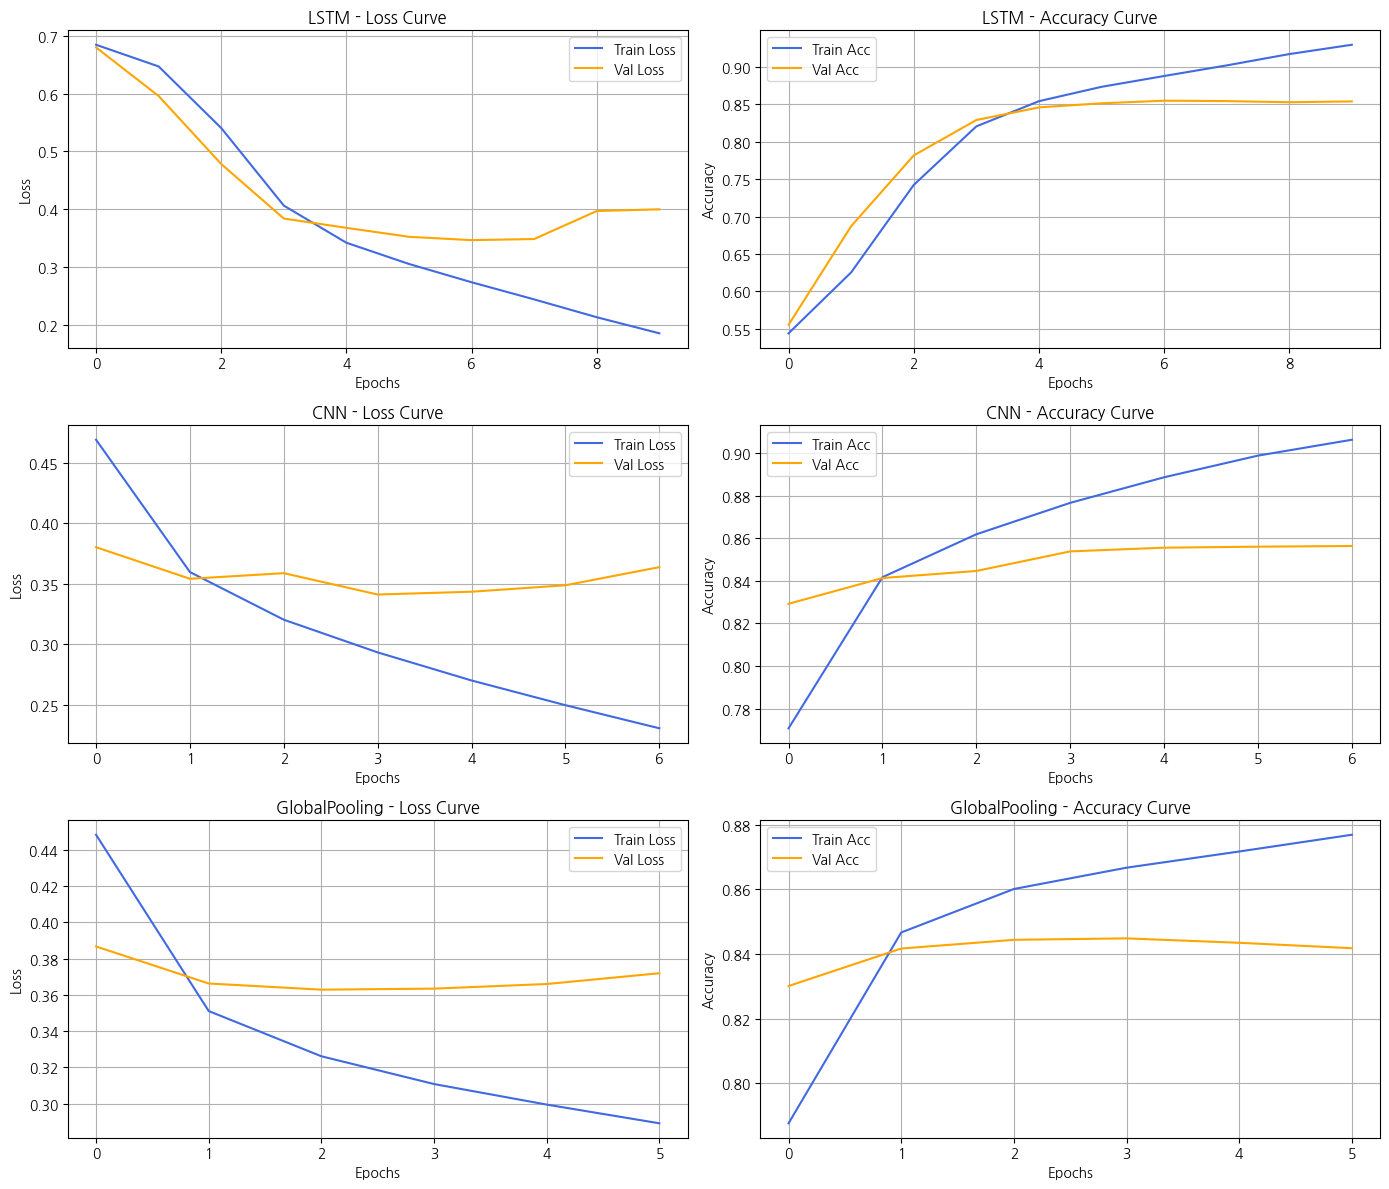


===== [학습된 Embedding 레이어 자체 분석 (타겟: '끝')] =====
 ➔ 순위 1: 구멍 (유사도: 0.4138)
 ➔ 순위 2: 밋밋 (유사도: 0.4023)
 ➔ 순위 3: 실체 (유사도: 0.3591)
 ➔ 순위 4: 글쎄 (유사도: 0.3578)
 ➔ 순위 5: 렵니다 (유사도: 0.3530)
 ➔ 순위 6: 따분 (유사도: 0.3473)
 ➔ 순위 7: 장교 (유사도: 0.3429)
 ➔ 순위 8: 대작 (유사도: 0.3411)
 ➔ 순위 9: 나타난 (유사도: 0.3398)
 ➔ 순위 10: 조디포스터 (유사도: 0.3264)

🚀 외부 사전학습 한국어 Word2Vec 로드 시도 -> /home/ysoh1113/workspace/projects/AIFFEL_quest_rs/Exploration/Ex05/../../work/sentiment_classification/data/word2vec_ko.model
📈 가용 어휘 바인딩 완성도 로그: 9457/9997 단어 매핑 연동.
🔓 Word2Vec 임베딩 레이어 동결 해제 완료. (Fine-tuning 활성화)

🚀 LSTM 모델 학습 개시 (최대 에포크: 15, LR: 0.001) ...
 Epoch 01/15 | Train Loss: 0.2452, Acc: 0.9013 | Val Loss: 0.3629, Acc: 0.8524
 📉 Validation loss 감소함 (inf --> 0.362864). 가중치 백업 중...
 Epoch 02/15 | Train Loss: 0.2148, Acc: 0.9156 | Val Loss: 0.3668, Acc: 0.8476
 EarlyStopping counter: 1 out of 3
 Epoch 03/15 | Train Loss: 0.1841, Acc: 0.9296 | Val Loss: 0.4061, Acc: 0.8539
 EarlyStopping counter: 2 out of 3
 Epoch 04/15 | Train Loss: 0.157

In [ ]:
# Execution 2

# 1. 전처리된 훈련/테스트 데이터 및 단어 인덱스 딕셔너리 추출
X_train, y_train, X_test, y_test, word_to_index = data_handler.get_preprocessed_train_test_data_and_word_to_index()


# 2. TrainHandler 인스턴스 초기화
print("🎬 감성 분류 훈련 관할 핸들러(TrainHandler) 초기화 중...")
train_handler = TrainHandler(
    base_path=base_path,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    word_index=word_to_index
)
# 3. 데이터 분석 및 pad_sequence 기반 패딩 추가 (단계 3 수행)
# max_len을 지정을 안 하면 '평균 + 2*표준편차' 크기로 자동 상한선 스크리닝이 작동합니다.
train_handler.analyze_data(max_len=None)


# 4. Validation Set 구성 및 PyTorch DataLoader 빌드 (단계 4-1 수행)
# 검증 세트 비율 20%, 배치 크기는 대중적인 64로 세팅
train_handler.make_validation_set(val_ratio=0.2, batch_size=64)


# 5. 베이스라인 아키텍처 3종 설정 (단계 4-2 수행)
train_handler.config_models(embedding_dim=100, hidden_dim=128)


# 6. 베이스라인 모델 3종 독립 훈련 개시 (단계 5 수행)
train_handler.train(epochs=15, lr=0.001)


# 7. 훈련 프로세스 손실(Loss) 및 정확도(Accuracy) 모니터링 시각화 (단계 6 수행)
train_handler.visualization()


# 8. 밑바닥부터 학습된 Embedding 레이어 기하 구조 분석 (단계 7 수행)
# 예시 지침에 나온 타겟 단어 '끝'에 대해 가장 가깝게 매핑된 의미적 유사어 탑 10 추출
train_handler.analyze_train_result(target_word='끝', top_n=10)


# 9. 외부 사전학습 한국어 Word2Vec 임베딩 전이학습 및 성능 개선 대조 실험 (단계 8 수행)
# word2vec_ko.model을 로드하여 고차원(100차원) 임베딩 공간에서 Fine-tuning 15에포크 수행
train_handler.compare_models(word2vec_file_name='word2vec_ko.model', embedding_dim=100, epochs=15)

## 프로젝트 회고

---

### 1. 프로젝트 개요

- 목적: 네이버 영화 리뷰 데이터셋(NSMC)을 활용하여 감성 이진 분류(Sentiment Classification) 모델을 구축하고, 밑바닥부터 학습하는 임베딩 레이어(Random Initialization)와 사전학습된 한국어 워드 임베딩(Word2Vec) 레이어의 순수 성능 차이를 검증한다.

- 핵심 통제 조건: 실험의 정밀성을 위해 모델의 후단 아키텍처(nn.LSTM, hidden_dim=128, 단방향, Dropout 없음) 및 데이터 처리 환경(100차원 차원 일치)을 100% 동일하게 통제하여 임베딩 공간의 초깃값과 훈련 방식에 따른 독립 변수 실험을 수행함.


### 2. 핵심 실험 결과 요약

최종 최적화된 학습 파이프라인을 통해 도출된 베이스라인 모델과 제안 모델의 최종 검증 점수(Validation Accuracy) 대조 결과는 다음과 같습니다. 

| 실험 세팅 (Experimental Setup) | 가중치 초기화 방식 | 임베딩 차원 (Dim) | 가중치 훈련 모드 | 최고 검증 정확도 (**Validation Acc**) |
| :--- | :--- | :---: | :--- | :---: |
| **Random Embedding + LSTM** <br>*(Baseline)* | 무작위 난수 (Random) | 100 | Full-Training (`lr=0.001`) | **0.8524 (85.24%)** |
| **Word2Vec Embedding + LSTM** <br>*(Proposed)* | `word2vec_ko.model` | 100 | Fine-Tuning (`lr=0.0002`) | **0.8575 (85.75%)** 🏆 |

